In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from ucimlrepo import fetch_ucirepo
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
import seaborn as sns

In [5]:
dataset = fetch_ucirepo("Concrete Compressive Strength")
X = dataset.data.features
y = dataset.data.targets

In [7]:

kernel = (
    ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.05)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=42,
)

kf = KFold(
    n_splits=10,
    shuffle=True,
    random_state=88
)

x_test_all = []
y_test_all = []
y_pred_all = []
y_std_all = []

for fold, (train_index, test_index) in enumerate(kf.split(X)):
    x_train, x_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    gp.fit(x_train, y_train)
    print(f"Fold {fold+1} completed.")
    y_pred, y_std = gp.predict(x_test, return_std=True)
    x_test_all.append(x_test)
    y_test_all.append(y_test)  
    y_pred_all.append(y_pred)
    y_std_all.append(y_std)

x_test_all = np.concatenate(x_test_all)
y_test_all = np.concatenate(y_test_all)
y_pred_all = np.concatenate(y_pred_all)
y_std_all = np.concatenate(y_std_all)



Fold 1 completed.
Fold 2 completed.
Fold 3 completed.
Fold 4 completed.
Fold 5 completed.
Fold 6 completed.
Fold 7 completed.
Fold 8 completed.
Fold 9 completed.
Fold 10 completed.


In [2]:
x_test = x_test_all
y_test = y_test_all
y_pred = y_pred_all
y_std = y_std_all

NameError: name 'x_test_all' is not defined

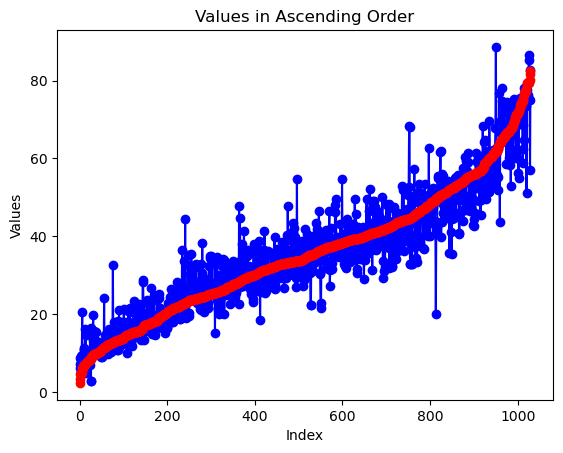

In [64]:
data_combined = list(zip(y_test, y_pred, y_std))
sorted_values = sorted(data_combined, key=lambda x: x[0])
x_data = []
y_test, y_pred, y_std = zip(*sorted_values)
for i in range(len(y_test)):
    x_data.append(i)
plt.plot(x_data, y_pred, marker='o', linestyle='-', color='b')
plt.plot(x_data, y_test, marker='o', linestyle='-', color='r')
plt.title("Values in Ascending Order")
plt.xlabel("Index")
plt.ylabel("Values")
plt.show()

In [ ]:
(np.mean((y_test-y_pred)**2) )** (1/2)

In [ ]:
from sklearn.datasets import fetch_openml
X, y = fetch_openml(data_id=189, return_X_y=True, as_frame=True)


In [ ]:
# for each file, copy file name, open file, copy file data, append file data and name into new file, repeat for all files, save new file as combined_data.py


In [17]:
from pathlib import Path

folder_path = Path("C:\\Users\\rajfr\\OneDrive\\Desktop\\test_files")

files = [f for f in folder_path.iterdir() if f.is_file()]

files_sorted = sorted(files, key=lambda x: x.stat().st_mtime)
combined_file = Path("C:\\Users\\rajfr\\OneDrive\\Desktop\\test_files\\combined_data.csv")

with open(combined_file, "a") as f:
    f.write("Chemical,Source,Temperature (K),Phase boundary pressure (kPa),Uncertainty of Phase boundary pressure (kPa),Smooth\n")
    for file in files_sorted:
        file_name_raw = file.name
        chemical_name = file_name_raw.split("_")[1][:-4]
        with open(file, "r") as g:
            next(g)
            file_data = g.read()
            print(file_data)
            for line in file_data.splitlines():
                f.write(f"{chemical_name},{line}\n")
    

1967 mur kiv 0,289.54,12.5056,0.0667
1967 mur kiv 0,291.479,13.9722,0.0800
1967 mur kiv 0,295.517,17.8785,0.0933
1967 mur kiv 0,300.405,23.3847,0.120
1967 mur kiv 0,303.634,28.091,0.147
1967 mur kiv 0,308.282,35.1971,0.173
1967 mur kiv 0,311.381,41.3166,0.213
1967 mur kiv 0,317.869,56.182,0.280
1967 mur kiv 0,325.576,78.7402,0.400
1967 mur kiv 0,331.964,102.005,0.520
1969 ano 2,331.335,101,
1973 roc sym 0,294.205,16.99,0.750
1973 roc sym 0,294.875,17.7,0.750
1973 roc sym 0,296.375,19.49,0.770
1973 roc sym 0,296.495,19.3,0.760
1973 roc sym 0,297.844,21.12,0.780
1973 roc sym 0,298.614,22.04,0.780
1973 roc sym 0,299.224,21.57,0.780
1973 roc sym 0,299.674,23.35,0.790
1973 roc sym 0,300.424,24.05,0.790
1973 roc sym 0,301.224,25.42,0.800
1973 roc sym 0,302.493,26.87,0.830
1973 roc sym 0,302.543,27.24,0.830
1973 roc sym 0,304.493,29.84,0.840
1973 roc sym 0,304.583,30.28,0.840
1973 roc sym 0,305.952,32.42,0.850
1973 roc sym 0,306.572,33.33,0.850
1973 roc sym 0,307.472,34.82,0.860
1973 roc sym 

In [ ]:
import scipy.stats.qmc as qmc


qmc.LatinHypercube()


TypeError: LatinHypercube.__init__() got an unexpected keyword argument 'n_samples'